# Exploratory Data Analysis

___

#### 1. Setup

In [83]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import load_and_process_lichess_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from pandas import DataFrame, Series, Index

In [ ]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [9, 5]
plt.rcParams['figure.dpi'] = 120

In [85]:
TARGET_ROWS: int = 100000

RAW_FILE: str = 'lichess_db_standard_rated_2016-07.pgn.zst'
RAW_PATH: Path = Path('../data') / RAW_FILE

PROCESSED_FILE: str = f'lichess_processed_{TARGET_ROWS}.csv'
PROCESSED_PATH: Path = Path('../data') / PROCESSED_FILE

df: DataFrame = load_and_process_lichess_data(RAW_PATH, PROCESSED_PATH, target_rows=TARGET_ROWS)

Clean data already exists at ../data/lichess_processed_100000.csv. Loading existing file...


___

#### 2. Data Overview

In [86]:
print('\n=== Dataset Preview ===')
df.head()


=== Dataset Preview ===


,skill_tier,game_elo,white_elo,black_elo,abs_rating_diff,higher_rated_color,base_time,increment,speed_category,opening_eco,...,black_moves,white_castled,black_castled,white_developed,black_developed,white_queen_moved,black_queen_moved,is_upset,termination_category,winner
0,Advanced,1898.5,1901,1896,5,1,300,5,Classical,D10,...,d7d5 c7c6 a7a6 e7e5 e5e4 c6d5 c8d7 b8d7 g8f6 f...,0,1,12,12,1,1,0,Time forfeit,1
1,Advanced,1634.0,1641,1627,14,1,300,0,Blitz,C20,...,e7e5 g8f6 b8c6 d7d6 g7g6 f8g7 c8e6 d8d7 e8g8 b...,1,1,12,12,0,1,1,Normal,0
2,Advanced,1667.5,1647,1688,41,0,180,0,Blitz,B01,...,d7d5 d8d5 c8g4 g8f6 d5d8 b8c6 e7e6 g4h5 f8d6 c...,1,0,11,12,1,1,1,Time forfeit,1
3,Advanced,1922.5,1945,1900,45,1,180,0,Blitz,B90,...,c7c5 d7d6 c5d4 g8f6 a7a6 d8c7 b7b5 c8b7 b8d7 g...,1,1,11,12,1,1,1,Time forfeit,0
4,Advanced,1791.0,1773,1809,36,0,180,0,Blitz,C27,...,e7e5 d7d6 h7h6 c7c6 d8f6 b7b5 c8e6 f8e7 d6e5 b...,1,0,11,12,1,1,0,Normal,0


In [87]:
print('=== Dataset Dimensions ===')
print(f'Total Games: {df.shape[0]:,}')
print(f'Total Features: {df.shape[1]}')

print('\n=== Missing Value Audit ===')
print(df.isnull().sum())

=== Dataset Dimensions ===
Total Games: 100,000
Total Features: 22

=== Missing Value Audit ===
skill_tier              0
game_elo                0
white_elo               0
black_elo               0
abs_rating_diff         0
higher_rated_color      0
base_time               0
increment               0
speed_category          0
opening_eco             0
opening_name            0
white_moves             0
black_moves             0
white_castled           0
black_castled           0
white_developed         0
black_developed         0
white_queen_moved       0
black_queen_moved       0
is_upset                0
termination_category    0
winner                  0
dtype: int64


In [88]:
print('\n=== Statistical Summary of Core Metrics ===')
df.describe().T


=== Statistical Summary of Core Metrics ===


,count,mean,std,min,25%,50%,75%,max
game_elo,100000.0,1736.909085,243.935142,856.5,1568.5,1735.5,1898.5,2687.0
white_elo,100000.0,1737.936310,263.354846,799.0,1557.0,1738.0,1914.0,2737.0
black_elo,100000.0,1735.881860,265.158962,738.0,1555.0,1735.0,1913.0,2731.0
abs_rating_diff,100000.0,147.851610,139.486881,0.0,46.0,106.0,206.0,1258.0
higher_rated_color,100000.0,0.502700,0.499995,0.0,0.0,1.0,1.0,1.0
base_time,100000.0,315.813450,394.021675,0.0,120.0,240.0,360.0,10800.0
increment,100000.0,1.202410,4.121166,0.0,0.0,0.0,1.0,180.0
white_castled,100000.0,0.603570,0.489158,0.0,0.0,1.0,1.0,1.0
black_castled,100000.0,0.541820,0.498251,0.0,0.0,1.0,1.0,1.0
white_developed,100000.0,11.240560,1.126873,3.0,11.0,12.0,12.0,12.0


In [89]:
print('=== Column Feature Types ===')
print(df.dtypes)

=== Column Feature Types ===
skill_tier               object
game_elo                float64
white_elo                 int64
black_elo                 int64
abs_rating_diff           int64
higher_rated_color        int64
base_time                 int64
increment                 int64
speed_category           object
opening_eco              object
opening_name             object
white_moves              object
black_moves              object
white_castled             int64
black_castled             int64
white_developed           int64
black_developed           int64
white_queen_moved         int64
black_queen_moved         int64
is_upset                  int64
termination_category     object
winner                    int64
dtype: object


___

#### 3. Target Variable Analysis: `is_upset`

=== Anomaly Base Distribution ===
Normal Outcome (0)  : 65,519 matches (65.52%)
Upset Anomaly (1)   : 34,481 matches (34.48%)


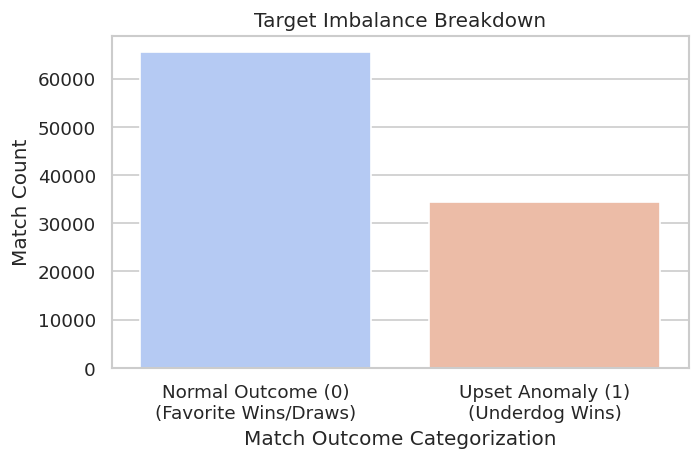

In [90]:
target_counts: Series = df['is_upset'].value_counts()
target_proportions: Series = df['is_upset'].value_counts(normalize=True)

print('=== Anomaly Base Distribution ===')
for idx, count in target_counts.items():
    label: str = 'Upset Anomaly (1)' if idx == 1 else 'Normal Outcome (0)'
    print(f'{label:<20}: {count:>6,} matches ({target_proportions[idx]*100:.2f}%)')

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_upset', data=df, hue='is_upset', palette='coolwarm', legend=False)
plt.xticks([0, 1], ['Normal Outcome (0)\n(Favorite Wins/Draws)', 'Upset Anomaly (1)\n(Underdog Wins)'])
plt.xlabel('Match Outcome Categorization')
plt.ylabel('Match Count')
plt.title('Target Imbalance Breakdown')
plt.tight_layout()
plt.show()

___

#### 4. Continuous Features

In [91]:
print('=== Absolute Rating Gap Distribution by Outcome ===')
display(df.groupby('is_upset')['abs_rating_diff'].describe())

print('\n=== Average Early Piece Development ===')
display(df.groupby('is_upset')[['white_developed', 'black_developed']].mean())

=== Absolute Rating Gap Distribution by Outcome ===


,count,mean,std,min,25%,50%,75%,max
is_upset,,,,,,,,
0,65519.0,171.503167,152.170527,0.0,58.0,129.0,241.0,1258.0
1,34481.0,102.910153,96.670161,1.0,33.0,75.0,143.0,1058.0



=== Average Early Piece Development ===


,white_developed,black_developed
is_upset,,
0,11.232391,11.120759
1,11.256083,11.141991


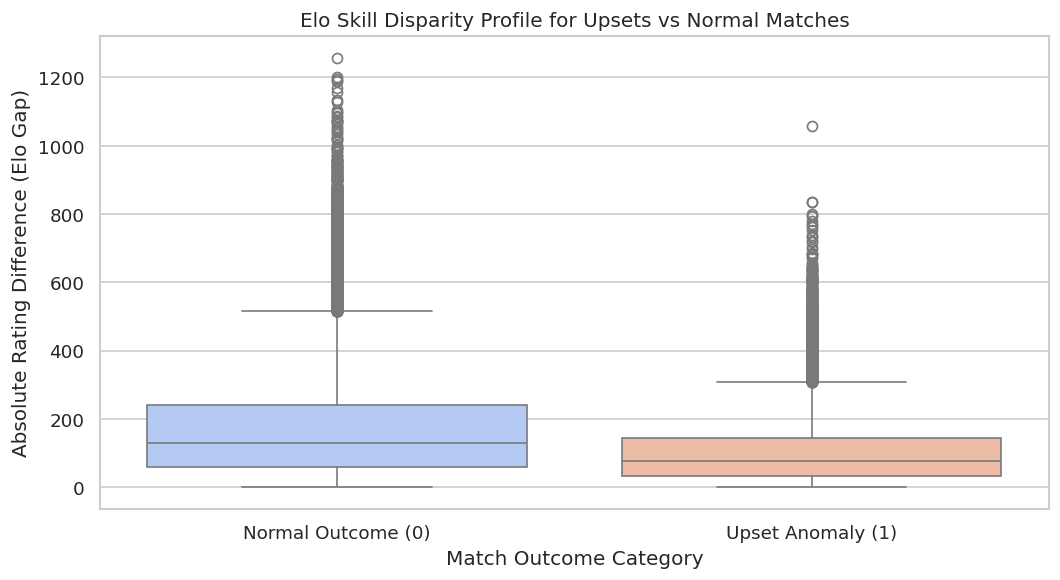

In [121]:
sns.boxplot(x='is_upset', y='abs_rating_diff', data=df, hue='is_upset', palette='coolwarm', legend=False)
plt.xticks([0, 1], ['Normal Outcome (0)', 'Upset Anomaly (1)'])
plt.xlabel('Match Outcome Category')
plt.ylabel('Absolute Rating Difference (Elo Gap)')
plt.title('Elo Skill Disparity Profile for Upsets vs Normal Matches')
plt.tight_layout()
plt.show()

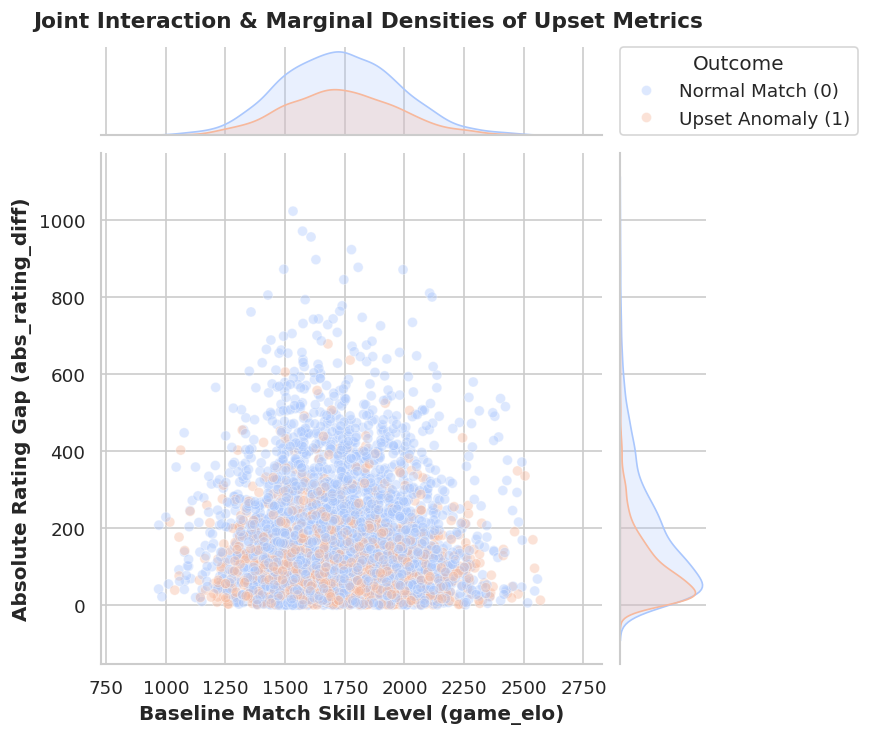

In [190]:
df_sample = df.sample(5000, random_state=42)
df_sample['Outcome'] = df_sample['is_upset'].map({0: 'Normal Match (0)', 1: 'Upset Anomaly (1)'})

fig: sns.JointGrid = sns.jointplot(
    x='game_elo', 
    y='abs_rating_diff', 
    data=df_sample, 
    hue='Outcome', 
    palette='coolwarm_r',
    alpha=0.4,
    kind='scatter'
)

fig.figure.suptitle('Joint Interaction & Marginal Densities of Upset Metrics', y=1.02, fontsize=13, fontweight='bold')
fig.set_axis_labels('Baseline Match Skill Level (game_elo)', 'Absolute Rating Gap (abs_rating_diff)', fontweight='bold')

plt.legend(title='Outcome', bbox_to_anchor=(1.036, 1.207), loc='upper left', borderaxespad=0, reverse=True)
plt.show()

___

#### 5. Categorical Features

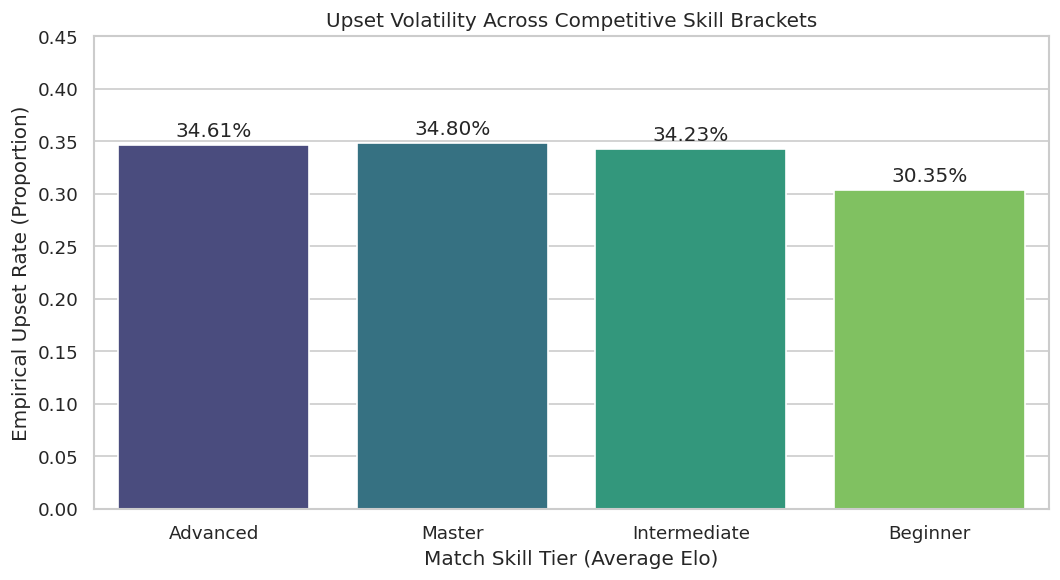

In [110]:
tier_stats: DataFrame = (
    df.groupby('skill_tier')['is_upset']
    .agg(['count', 'mean'])
    .reindex(df['skill_tier'].unique())
)

sns.barplot(
    x=tier_stats.index, 
    y='mean', 
    data=tier_stats.reset_index(), 
    hue='skill_tier', 
    palette='viridis', 
    legend=False
)
plt.xlabel('Match Skill Tier (Average Elo)')
plt.ylabel('Empirical Upset Rate (Proportion)')
plt.title('Upset Volatility Across Competitive Skill Brackets')

for i, val in enumerate(tier_stats['mean']):
    plt.text(i, val + 0.005, f'{val*100:.2f}%', ha='center', va='bottom')

plt.ylim(0, 0.45)
plt.tight_layout()
plt.show()

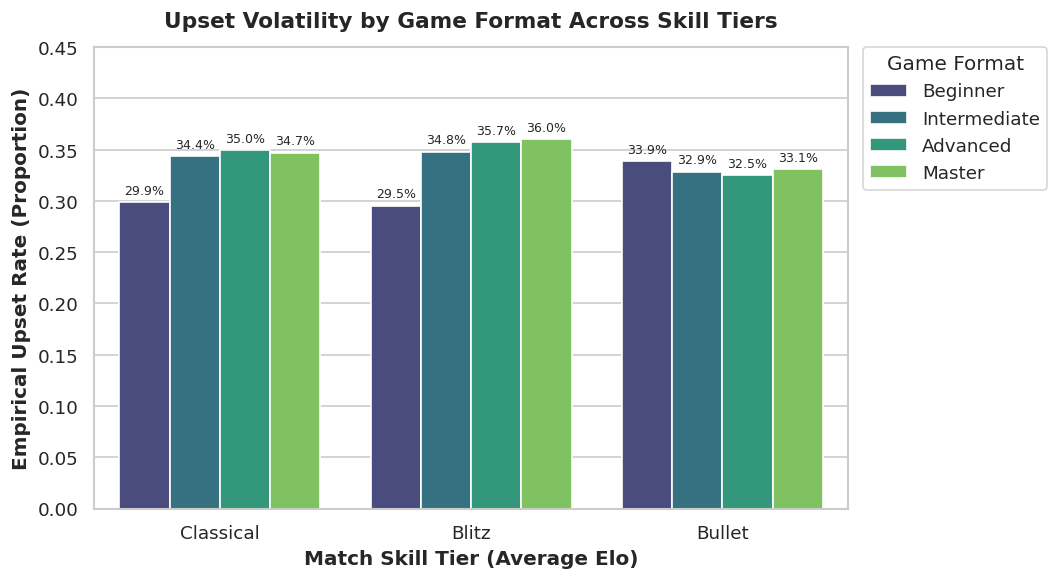

In [106]:
tier_order: list[str] = ['Beginner', 'Intermediate', 'Advanced', 'Master']
speed_tier_stats: DataFrame = df.groupby(['skill_tier', 'speed_category'])['is_upset'].mean().reset_index()

ax1: plt.Axes = sns.barplot(
    x='speed_category', 
    y='is_upset', 
    hue='skill_tier', 
    data=speed_tier_stats, 
    hue_order=tier_order,
    order=df['speed_category'].unique(), 
    palette='viridis'
)
plt.xlabel('Match Skill Tier (Average Elo)', fontweight='bold')
plt.ylabel('Empirical Upset Rate (Proportion)', fontweight='bold')
plt.title('Upset Volatility by Game Format Across Skill Tiers', fontsize=13, fontweight='bold', pad=12)
plt.legend(title='Game Format', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.ylim(0, 0.45)

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height()*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=7.5, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

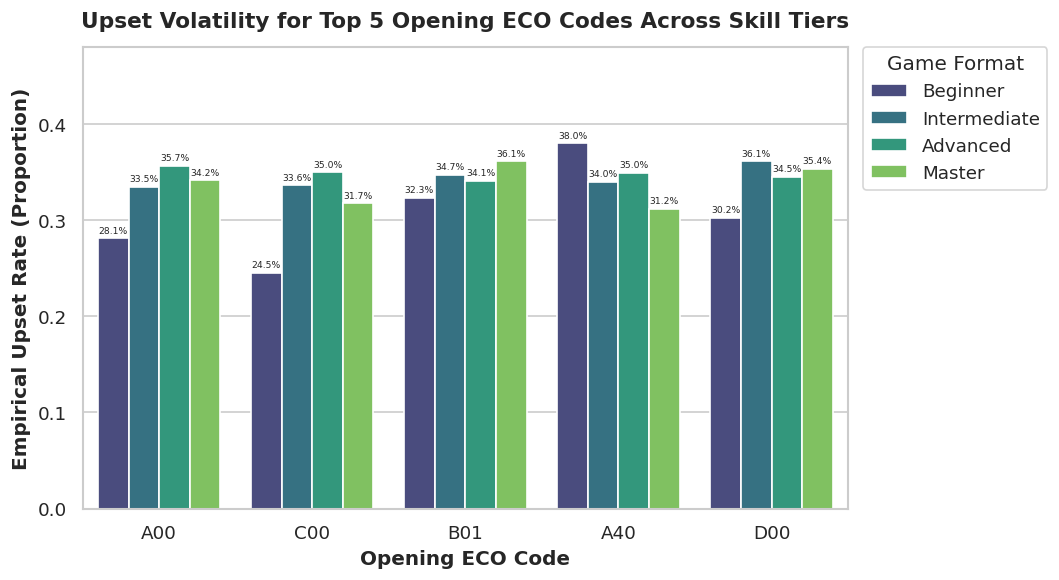

In [111]:
top_5_ecos: list[str] = df['opening_eco'].value_counts().head(5).index.tolist()
eco_tier_stats: DataFrame = df[df['opening_eco'].isin(top_5_ecos)].groupby(['skill_tier', 'opening_eco'])['is_upset'].mean().reset_index()

ax2: plt.Axes = sns.barplot(
    x='opening_eco', 
    y='is_upset', 
    hue='skill_tier', 
    data=eco_tier_stats, 
    order=top_5_ecos, 
    hue_order=tier_order,
    palette='viridis'
)
plt.xlabel('Opening ECO Code', fontweight='bold')
plt.ylabel('Empirical Upset Rate (Proportion)', fontweight='bold')
plt.title('Upset Volatility for Top 5 Opening ECO Codes Across Skill Tiers', fontsize=13, fontweight='bold', pad=12)
plt.legend(title='Game Format', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.ylim(0, 0.48)

for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{p.get_height()*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=5.5, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

___

#### 6. Core Takeaways & Model Motivation

##### 6.1 The EDA-to-Modeling Blueprint
The following matrix maps our empirical data discoveries directly to our feature engineering and model selection strategy:

| EDA Discovery | Statistical Real-World Meaning | Machine Learning Pipeline Impact |
| :--- | :--- | :--- |
| **34.48% Minority Base Rate** | Class imbalance is present; default models will over-predict normal outcomes. | We must optimize using **F1-Score / Precision Lift** and tune the decision threshold rather than relying on raw Accuracy. |
| **Triangular Elo Boundary** | Rating gaps lose predictive power in low-Elo brackets due to high unforced blunder rates. | Motivates **Tree Ensembles (XGBoost/LightGBM)** which naturally calculate non-linear splits on feature interactions. |
| **Format Divergence** | Bullet matches act as chaotic coin flips for beginners but stabilize for master-level players. | Confirms that environmental variables cannot be evaluated linearly without an anchor feature like `game_elo`. |
| **Opening Trap Volatility** | Sharp opening lines (like `A40`) spike upset rates for underdogs, but only in lower tiers. | We will use cross-validated **Target Encoding** on categorical opening tags to safely pass these signals to tree leaves. |

##### 6.2 Formal Modeling Hypotheses
Based on our exploratory data analysis, we establish three core hypotheses that our gradient boosted tree framework is uniquely positioned to evaluate:

* **Hypothesis 1:** Under conditions where $speed\_category = \text{'Blitz'}$ and $game\_elo < 1400$, the predictive feature importance of $abs\_rating\_diff$ will drop significantly compared to Master-tier matches.
* **Hypothesis 2:** Matches where a favorite exhibits $white\_castled = 0$ or $black\_castled = 0$ past the 24-ply threshold will correlate with a higher precision score for predicting an imminent upset anomaly.
* **Hypothesis 3:** Early queen sorties ($queen\_moved = 1$) executed by a favorite will serve as a strong proxy feature for player 'tilt' or erratic play style, increasing volatility metrics within fast time controls.

___